# ScyllaDB Vector Search Benchmark — 10M × 768 Dim (Cohere)

**Dataset:** 10M vectors · **768 dimensions** · COSINE similarity (Cohere)  
**Workload:** Search Performance Test (VectorDBBench)  
**Date:** 2026-04-01

### Hardware

| Role | Instance | Count |
|---|---|---|
| **Storage nodes** | i8g.large (16 GB RAM, 2 CPUs) | 3 |
| **Search nodes** | r7g.2xlarge (64 GB RAM, 8 CPUs) | 2 |

### Experiments

| Experiment | M | ef_construction | ef_search | k tested |
|---|---|---|---|---|
| **#1** (high quality) | 64 | 384 | 192 | 100, 10 |
| **#2** (balanced) | 32 | 256 | 128 | 100, 10 |
| **#3** (high throughput) | 24 | 256 | 64 | 10, 100 |
| **#4** (max throughput) | 20 | 256 | 48 | 10 |

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

CONC = [1, 5, 10, 20, 30, 40, 60, 80, 100, 120, 150]

# ── Experiment #1: M=64, ef_c=384, ef_s=192 ─────────────────────────────
exp1_k100 = {
    "conc": CONC,
    "qps":     [93.5495, 476.1601, 946.635, 1785.264, 2238.4467, 2342.1445, 2330.6089, 2319.8472, 2321.6046, 2337.073, 2344.8263],
    "lat_p99": [15.52, 15.21, 15.35, 16.51, 21.39, 28.76, 45.91, 63.75, 81.15, 96.30, 120.37],
    "lat_avg": [10.67, 10.48, 10.54, 11.16, 13.33, 16.95, 25.44, 33.85, 42.06, 49.43, 60.65],
    "recall": 0.9679,
    "ndcg": 0.9726,
    "serial_p99": 15.2,
}
exp1_k10 = {
    "conc": CONC,
    "qps":     [104.1492, 524.2487, 1054.1423, 1993.6748, 2266.9319, 2306.889, 2318.6592, 2320.2087, 2323.7791, 2309.4843, 2305.733],
    "lat_p99": [13.99, 14.08, 13.99, 15.78, 22.37, 30.06, 46.57, 63.32, 80.97, 98.24, 123.79],
    "lat_avg": [9.59, 9.52, 9.46, 9.99, 13.16, 17.22, 25.62, 33.99, 42.30, 50.93, 63.25],
    "recall": 0.9919,
    "ndcg": 0.9911,
    "serial_p99": 14.6,
}

# ── Experiment #2: M=32, ef_c=256, ef_s=128 ─────────────────────────────
exp2_k100 = {
    "conc": CONC,
    "qps":     [133.2427, 674.9222, 1313.6763, 2320.848, 2854.3334, 2974.8948, 2943.8741, 2891.7357, 2847.9077, 2853.0322, 2860.2897],
    "lat_p99": [9.92, 9.76, 10.02, 12.41, 17.47, 25.46, 34.02, 42.51, 49.88, 58.32, 67.47],
    "lat_avg": [7.49, 7.39, 7.59, 8.58, 10.45, 13.33, 20.05, 26.87, 33.85, 40.36, 49.17],
    "recall": 0.9196,
    "ndcg": 0.9313,
    "serial_p99": 9.6,
}
exp2_k10 = {
    "conc": CONC,
    "qps":     [154.691, 782.7091, 1601.7639, 3183.6102, 4412.4825, 4732.2878, 4851.819, 4896.5472, 4822.4448, 4820.6193, 4746.8385],
    "lat_p99": [8.52, 8.61, 8.29, 8.42, 10.12, 13.62, 21.19, 28.75, 38.09, 46.50, 59.60],
    "lat_avg": [6.45, 6.37, 6.23, 6.25, 6.76, 8.39, 12.23, 16.10, 20.32, 24.36, 30.38],
    "recall": 0.977,
    "ndcg": 0.9764,
    "serial_p99": 8.7,
}

# ── Experiment #3: M=24, ef_c=256, ef_s=64 ──────────────────────────────
exp3_k10 = {
    "conc": CONC,
    "qps":     [204.7607, 1014.6426, 2045.7066, 4280.2573, 6390.4545, 8095.7548, 9485.2488, 9719.2017, 9632.2966, 9586.1793, 9634.501],
    "lat_p99": [6.21, 6.31, 6.28, 6.26, 6.31, 6.97, 10.03, 13.68, 17.97, 22.24, 27.72],
    "lat_avg": [4.87, 4.92, 4.87, 4.65, 4.67, 4.90, 6.25, 8.09, 10.16, 12.11, 14.97],
    "recall": 0.9497,
    "ndcg": 0.9491,
    "serial_p99": 6.0,
}
exp3_k100 = {
    "conc": CONC,
    "qps":     [155.0958, 773.222, 1488.8992, 2474.2818, 2958.6693, 3024.9364, 2925.7719, 2901.7329, 2850.8991, 2773.025, 2822.117],
    "lat_p99": [8.14, 8.18, 8.74, 12.03, 18.50, 25.32, 34.39, 41.92, 49.63, 60.19, 70.12],
    "lat_avg": [6.44, 6.45, 6.70, 8.05, 10.08, 13.10, 20.11, 26.82, 33.92, 40.92, 49.45],
    "recall": 0.8794,
    "ndcg": 0.897,
    "serial_p99": 7.8,
}

# ── Experiment #4: M=20, ef_c=256, ef_s=48 (k=10 only) ──────────────────
exp4_k10 = {
    "conc": CONC,
    "qps":     [227.0314, 1163.3493, 2310.5528, 4740.0909, 6979.9704, 8980.0304, 11662.1288, 12682.0592, 12840.336, 12738.635, 12565.123],
    "lat_p99": [5.54, 5.49, 5.54, 5.52, 5.73, 6.10, 7.42, 9.52, 12.34, 15.64, 20.35],
    "lat_avg": [4.40, 4.29, 4.31, 4.20, 4.27, 4.42, 5.08, 6.19, 7.62, 9.17, 11.30],
    "recall": 0.9201,
    "ndcg": 0.9199,
    "serial_p99": 5.5,
}

EXPERIMENTS = {
    "#1 M=64 ef_s=192": {"k100": exp1_k100, "k10": exp1_k10},
    "#2 M=32 ef_s=128": {"k100": exp2_k100, "k10": exp2_k10},
    "#3 M=24 ef_s=64":  {"k100": exp3_k100, "k10": exp3_k10},
    "#4 M=20 ef_s=48":  {"k10": exp4_k10},
}

COLORS = {
    "#1 M=64 ef_s=192": "#6C3FC5",
    "#2 M=32 ef_s=128": "#E6812F",
    "#3 M=24 ef_s=64":  "#2196F3",
    "#4 M=20 ef_s=48":  "#4CAF50",
}
MARKERS = {
    "#1 M=64 ef_s=192": "o",
    "#2 M=32 ef_s=128": "s",
    "#3 M=24 ef_s=64":  "^",
    "#4 M=20 ef_s=48":  "D",
}

def _style(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

## 1. QPS vs Concurrency

How throughput scales with the number of concurrent search clients.

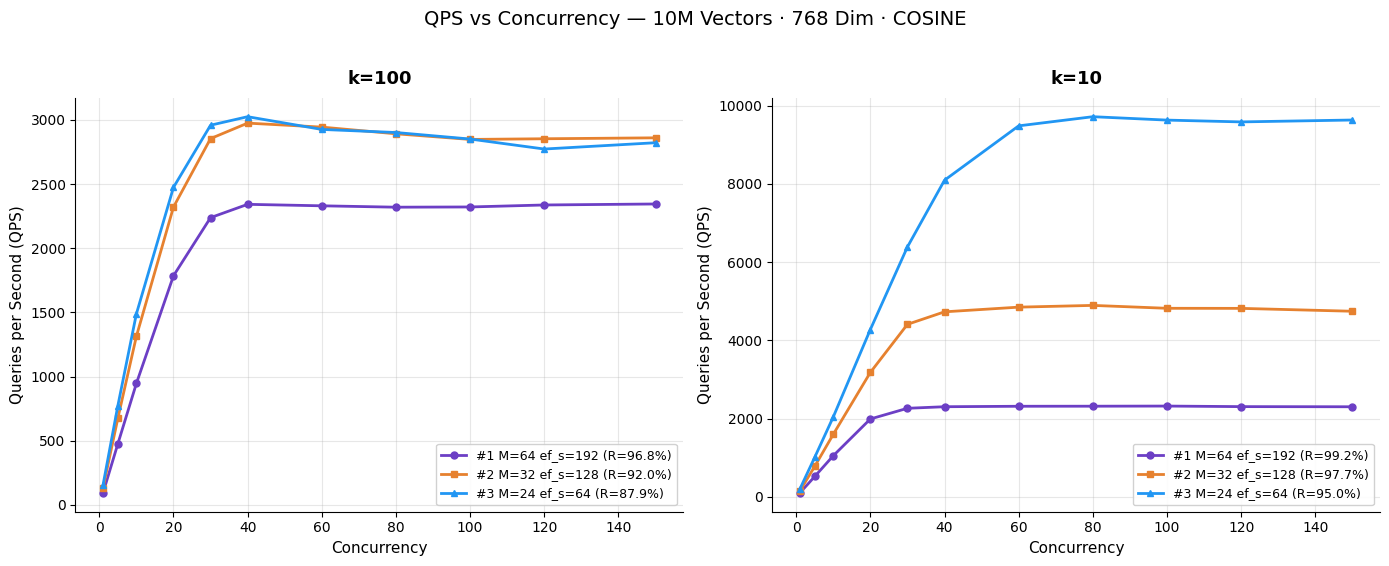

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, k_label, k_key in [(ax1, "k=100", "k100"), (ax2, "k=10", "k10")]:
    for name, data in EXPERIMENTS.items():
        if k_key not in data:
            continue
        d = data[k_key]
        ax.plot(d["conc"], d["qps"], f"{MARKERS[name]}-", color=COLORS[name],
                label=f'{name} (R={d["recall"]:.1%})', lw=2, ms=5)
    _style(ax, k_label, "Concurrency", "Queries per Second (QPS)")

fig.suptitle("QPS vs Concurrency — 10M Vectors · 768 Dim · COSINE", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 2. P99 Latency vs Concurrency

Tail latency behavior under increasing load.

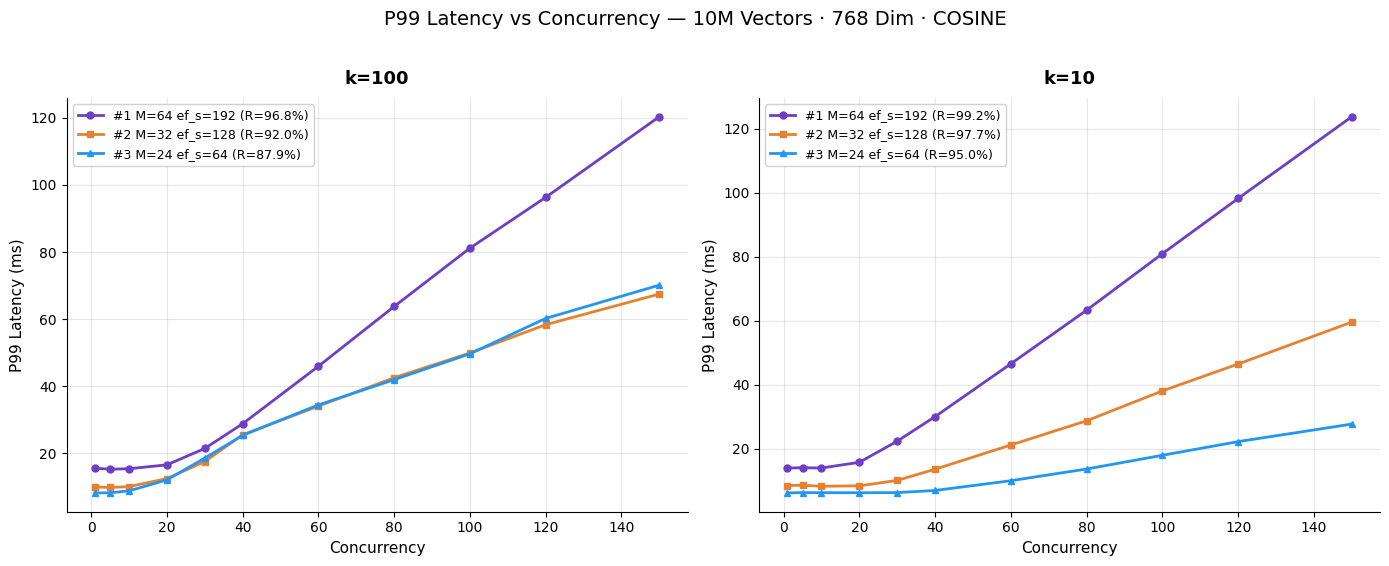

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, k_label, k_key in [(ax1, "k=100", "k100"), (ax2, "k=10", "k10")]:
    for name, data in EXPERIMENTS.items():
        if k_key not in data:
            continue
        d = data[k_key]
        ax.plot(d["conc"], d["lat_p99"], f"{MARKERS[name]}-", color=COLORS[name],
                label=f'{name} (R={d["recall"]:.1%})', lw=2, ms=5)
    _style(ax, k_label, "Concurrency", "P99 Latency (ms)")

fig.suptitle("P99 Latency vs Concurrency — 10M Vectors · 768 Dim · COSINE", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 3. Average Latency vs Concurrency

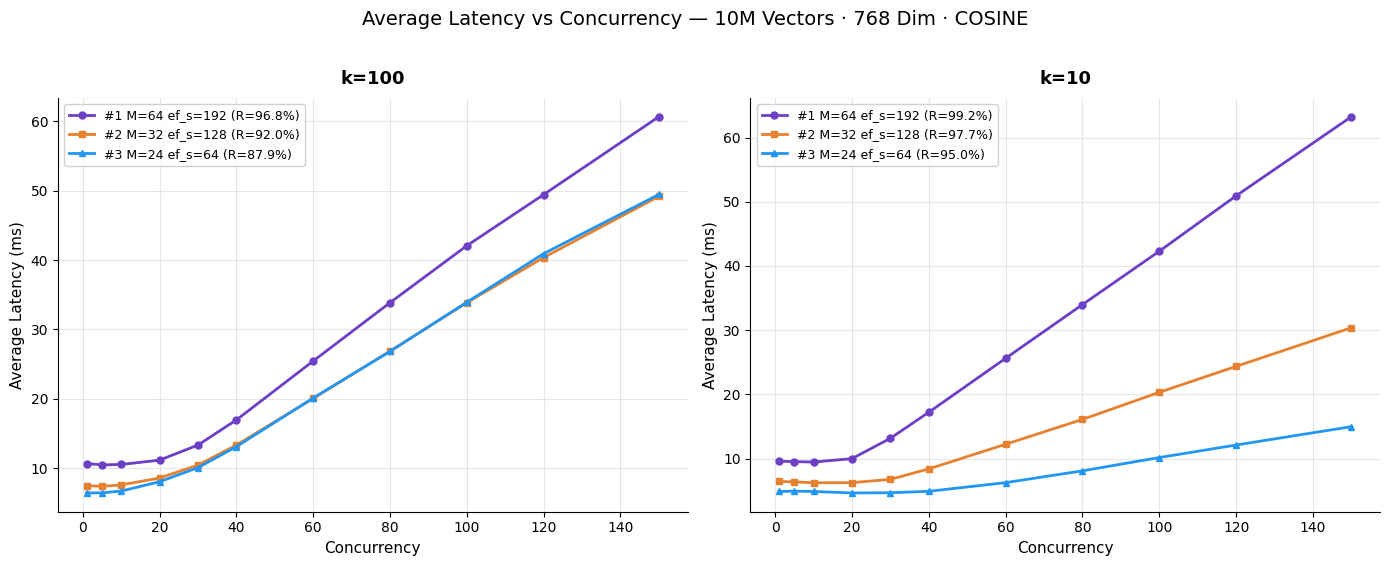

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, k_label, k_key in [(ax1, "k=100", "k100"), (ax2, "k=10", "k10")]:
    for name, data in EXPERIMENTS.items():
        if k_key not in data:
            continue
        d = data[k_key]
        ax.plot(d["conc"], d["lat_avg"], f"{MARKERS[name]}-", color=COLORS[name],
                label=f'{name} (R={d["recall"]:.1%})', lw=2, ms=5)
    _style(ax, k_label, "Concurrency", "Average Latency (ms)")

fig.suptitle("Average Latency vs Concurrency — 10M Vectors · 768 Dim · COSINE", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 4. Peak QPS Comparison

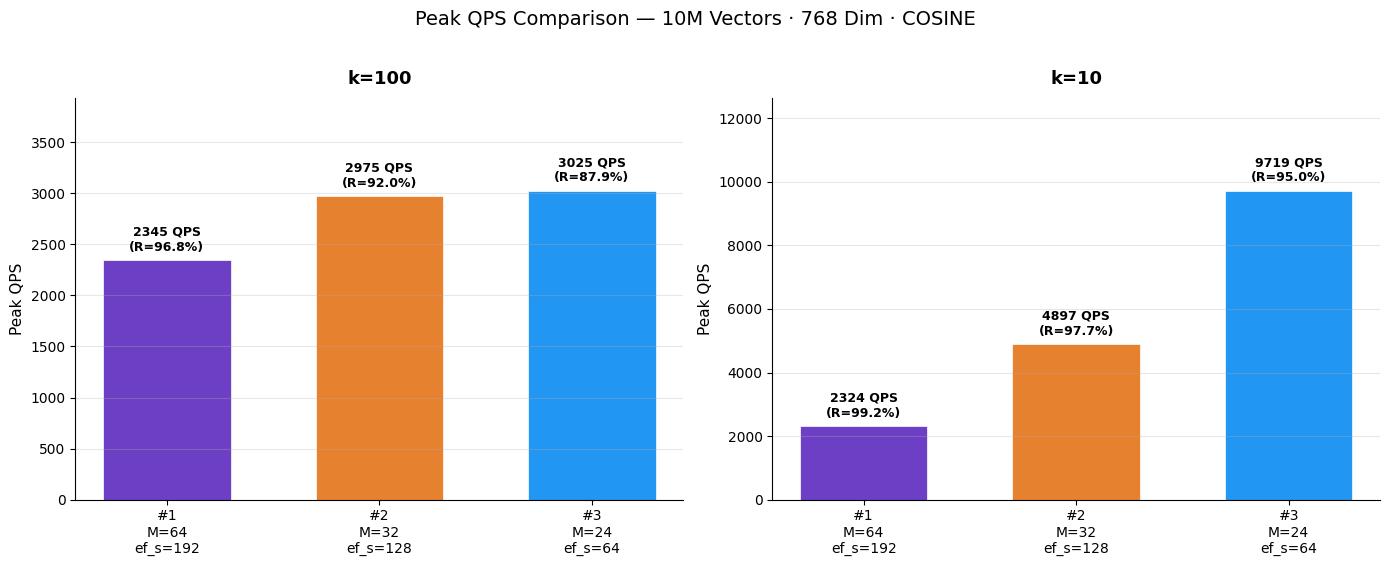

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, k_label, k_key in [(ax1, "k=100", "k100"), (ax2, "k=10", "k10")]:
    names = [n for n in EXPERIMENTS if k_key in EXPERIMENTS[n]]
    peaks = [max(EXPERIMENTS[n][k_key]["qps"]) for n in names]
    recalls = [EXPERIMENTS[n][k_key]["recall"] for n in names]
    colors = [COLORS[n] for n in names]
    labels = [n.replace(" ", "\n") for n in names]

    bars = ax.bar(labels, peaks, color=colors, edgecolor="white", lw=0.5, width=0.6)
    ymax = max(peaks)
    for bar, r in zip(bars, recalls):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + ymax * 0.02,
                f"{bar.get_height():.0f} QPS\n(R={r:.1%})", ha="center", va="bottom",
                fontsize=9, fontweight="bold")
    ax.set_ylim(0, ymax * 1.3)
    ax.set_title(k_label, fontsize=13, fontweight="bold", pad=10)
    ax.set_ylabel("Peak QPS", fontsize=11)
    ax.grid(True, alpha=0.3, axis="y")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Peak QPS Comparison — 10M Vectors · 768 Dim · COSINE", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 5. QPS vs P99 Latency (Pareto View)

Trade-off between throughput and tail latency. Points closer to the **top-left** corner are better (high QPS, low latency). Concurrency level annotated at key points.

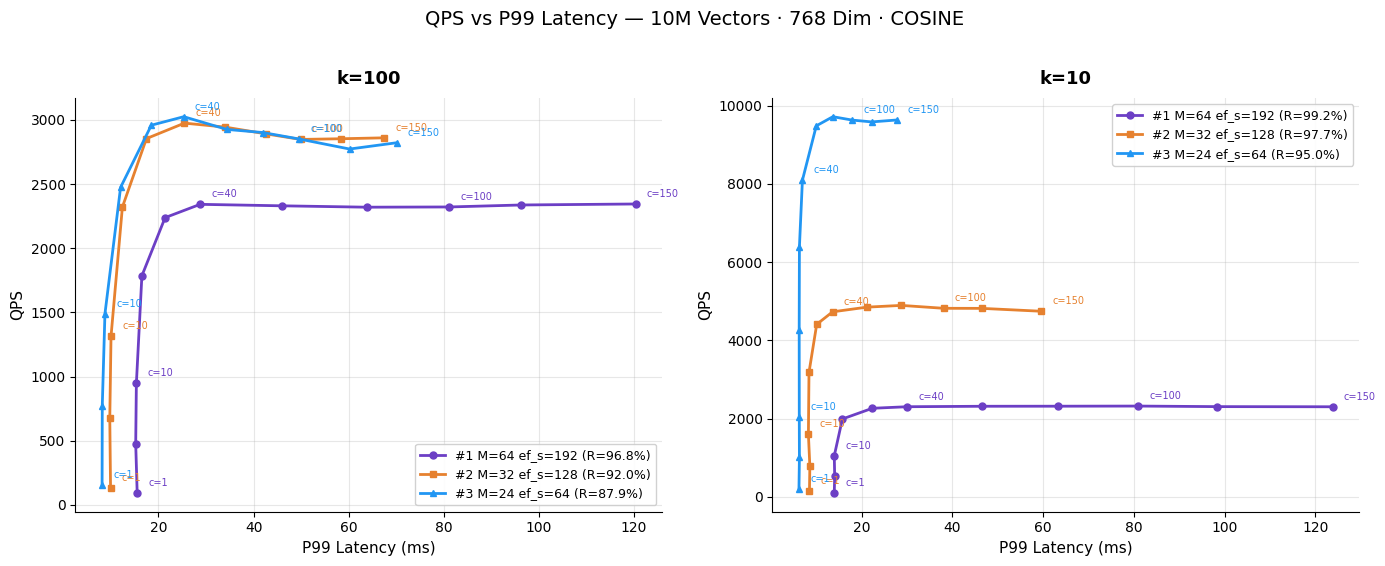

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, k_label, k_key in [(ax1, "k=100", "k100"), (ax2, "k=10", "k10")]:
    for name, data in EXPERIMENTS.items():
        if k_key not in data:
            continue
        d = data[k_key]
        ax.plot(d["lat_p99"], d["qps"], f"{MARKERS[name]}-", color=COLORS[name],
                label=f'{name} (R={d["recall"]:.1%})', lw=2, ms=5)
        for i, c in enumerate(d["conc"]):
            if c in (1, 10, 40, 100, 150):
                ax.annotate(f"c={c}", (d["lat_p99"][i], d["qps"][i]),
                            textcoords="offset points", xytext=(8, 5),
                            fontsize=7, color=COLORS[name])
    _style(ax, k_label, "P99 Latency (ms)", "QPS")

fig.suptitle("QPS vs P99 Latency — 10M Vectors · 768 Dim · COSINE", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 6. Recall vs Peak QPS Trade-off

How index parameters affect the recall-throughput trade-off.

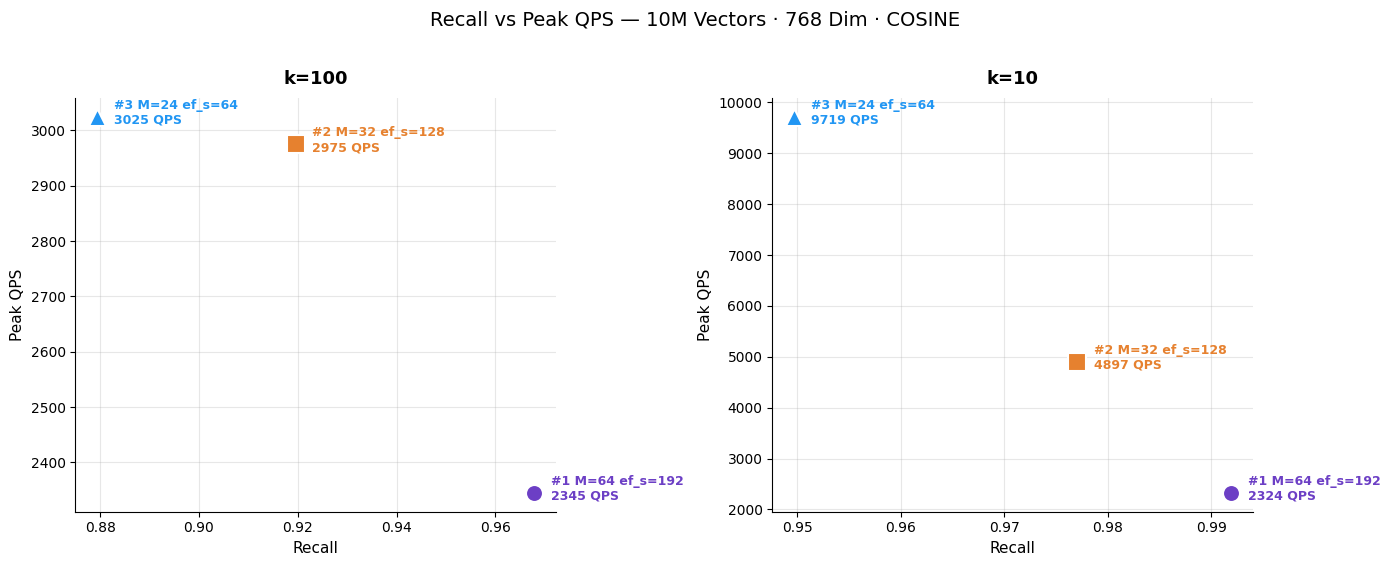

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, k_label, k_key in [(ax1, "k=100", "k100"), (ax2, "k=10", "k10")]:
    for name, data in EXPERIMENTS.items():
        if k_key not in data:
            continue
        d = data[k_key]
        peak_qps = max(d["qps"])
        ax.scatter(d["recall"], peak_qps, color=COLORS[name], s=150, marker=MARKERS[name],
                   zorder=5, edgecolors="white", linewidths=1.5)
        ax.annotate(f'{name}\n{peak_qps:.0f} QPS',
                    (d["recall"], peak_qps),
                    textcoords="offset points", xytext=(12, -5),
                    fontsize=9, color=COLORS[name], fontweight="bold")
    ax.set_title(k_label, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Recall", fontsize=11)
    ax.set_ylabel("Peak QPS", fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Recall vs Peak QPS — 10M Vectors · 768 Dim · COSINE", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 7. Summary

### k=100

| Metric | #1 M=64 ef_s=192 | #2 M=32 ef_s=128 | #3 M=24 ef_s=64 |
|---|---|---|---|
| **Peak QPS** | 2,345 (c=150) | 2,975 (c=40) | 3,025 (c=40) |
| **QPS @ c=10** | 947 | 1,314 | 1,489 |
| **Serial P99 Latency** | 15.2 ms | 9.6 ms | 7.8 ms |
| **P99 Latency @ c=1** | 15.5 ms | 9.9 ms | 8.1 ms |
| **P99 Latency @ c=100** | 81.2 ms | 49.9 ms | 49.6 ms |
| **Recall** | 96.8% | 92.0% | 87.9% |
| **nDCG** | 97.3% | 93.1% | 89.7% |

### k=10

| Metric | #1 M=64 ef_s=192 | #2 M=32 ef_s=128 | #3 M=24 ef_s=64 | #4 M=20 ef_s=48 |
|---|---|---|---|---|
| **Peak QPS** | 2,324 (c=100) | 4,897 (c=80) | 9,719 (c=80) | 12,840 (c=100) |
| **QPS @ c=10** | 1,054 | 1,602 | 2,046 | 2,311 |
| **Serial P99 Latency** | 14.6 ms | 8.7 ms | 6.0 ms | 5.5 ms |
| **P99 Latency @ c=1** | 14.0 ms | 8.5 ms | 6.2 ms | 5.5 ms |
| **P99 Latency @ c=100** | 81.0 ms | 38.1 ms | 18.0 ms | 12.3 ms |
| **Recall** | 99.2% | 97.7% | 95.0% | 92.0% |
| **nDCG** | 99.1% | 97.6% | 94.9% | 92.0% |

### Key Observations

- **k=10 throughput scales dramatically with lighter index params:** Exp #4 (M=20, ef_s=48) achieves **12,840 QPS** — **5.5× higher** than Exp #1 (M=64, ef_s=192) — while maintaining 92.0% recall
- **k=100 throughput is more constrained:** Peak QPS varies from 2,345 to 3,025 across configs (~1.3× range), as retrieving more neighbors dominates cost
- **Recall trade-off is modest at k=10:** Recall only drops from 99.2% → 92.0% (−7.2pp) going from heaviest to lightest config, while QPS increases 5.5×
- **Recall trade-off is steeper at k=100:** Recall drops from 96.8% → 87.9% (−8.9pp) for a 1.3× QPS gain
- **Latency improves proportionally:** Serial P99 latency drops from 15.2 ms → 7.8 ms at k=100, and 14.6 ms → 5.5 ms at k=10
- **Saturation point:** Experiments #1–#3 plateau around c=40–80 concurrency; Exp #4 scales further to c=100 before saturating
- **Best balanced config:** Exp #2 (M=32, ef_s=128) offers a good middle ground — 97.7% recall at k=10 with 4,897 QPS, and 92.0% recall at k=100 with 2,975 QPS